In [59]:
import seaborn as sns
import csv
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import pylab 
import scipy.stats as stats
from scipy import ndimage
import gmaps 
import gmaps.datasets 
import datetime

In [3]:
# Default plot configurations
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (20.0, 10.0)
sns.set()

from IPython.display import display, Latex, Markdown

In [4]:
# Set the Filepath
file_path = "data/pest/Medfly_infection_1_2017.csv"

# Read the Data
df = pd.read_csv(file_path)

In [5]:
df.head()

,,Scout,Date/Time,Grower,Location,Crop,Measurement,Data,Description,Latitude,Longitude,month
0,5178,Mata Elrom,1/11/17 8:42,Elrom,4335-א Pink,Apple - Pink lady,Medfly infection,0.0,% of inf. fruits,33.121059,35.789218,1
1,5179,Mata Elrom,1/11/17 8:41,Elrom,4335-א Pink,Apple - Pink lady,Medfly infection,0.0,% of inf. fruits,33.121059,35.789218,1
2,5180,Mata Elrom,1/11/17 8:27,Elrom,2990-2 Pink,Apple - Pink lady,Medfly infection,0.0,% of inf. fruits,33.120773,35.790868,1
3,5181,Mata Elrom,1/11/17 8:20,Elrom,2990-2 Pink,Apple - Pink lady,Medfly infection,0.0,% of inf. fruits,33.120773,35.790868,1
4,5220,Medfly project-system,1/11/17 0:00,Ortal,5520,Apple,Medfly infection,0.0,% of inf. fruits,33.084833,35.778632,1


In [6]:
data = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude))

In [7]:
data.head()

,,Scout,Date/Time,Grower,Location,Crop,Measurement,Data,Description,Latitude,Longitude,month,geometry
0,5178,Mata Elrom,1/11/17 8:42,Elrom,4335-א Pink,Apple - Pink lady,Medfly infection,0.0,% of inf. fruits,33.121059,35.789218,1,POINT (35.789218 33.121059)
1,5179,Mata Elrom,1/11/17 8:41,Elrom,4335-א Pink,Apple - Pink lady,Medfly infection,0.0,% of inf. fruits,33.121059,35.789218,1,POINT (35.789218 33.121059)
2,5180,Mata Elrom,1/11/17 8:27,Elrom,2990-2 Pink,Apple - Pink lady,Medfly infection,0.0,% of inf. fruits,33.120773,35.790868,1,POINT (35.790868 33.120773)
3,5181,Mata Elrom,1/11/17 8:20,Elrom,2990-2 Pink,Apple - Pink lady,Medfly infection,0.0,% of inf. fruits,33.120773,35.790868,1,POINT (35.790868 33.120773)
4,5220,Medfly project-system,1/11/17 0:00,Ortal,5520,Apple,Medfly infection,0.0,% of inf. fruits,33.084833,35.778632,1,POINT (35.778632 33.084833)


Distribution of the different crops.

In [37]:
crops = data['Crop'].value_counts()
crops

Apple                  292
Nectarine               82
Apricot                 52
Pears                   45
Plum                    42
Cherries                41
Peach                   38
Peach and nectarine     26
Apple - Pink lady        4
Quince                   1
Name: Crop, dtype: int64

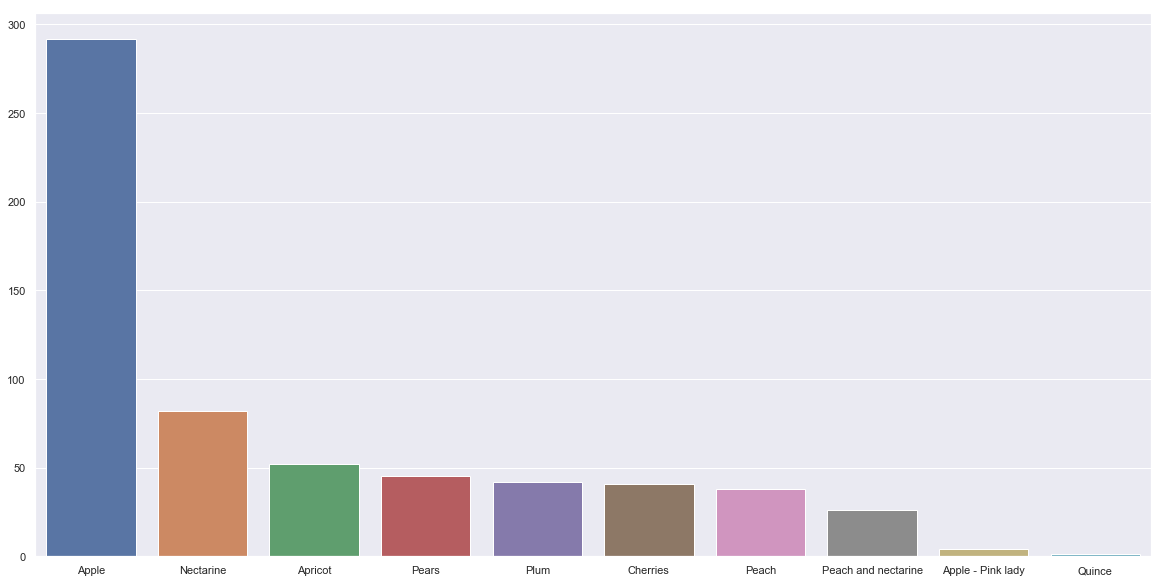

In [39]:
sns.barplot(crops.index, crops.values)

Load the world map.

In [41]:
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
israel = world[world['name'] == 'Israel']
world.head()

,pop_est,continent,name,iso_a3,gdp_md_est,geometry
0,920938,Oceania,Fiji,FJI,8374.0,"(POLYGON ((180 -16.06713266364245, 180 -16.555..."
1,53950935,Africa,Tanzania,TZA,150600.0,POLYGON ((33.90371119710453 -0.950000000000000...
2,603253,Africa,W. Sahara,ESH,906.5,POLYGON ((-8.665589565454809 27.65642588959236...
3,35623680,North America,Canada,CAN,1674000.0,"(POLYGON ((-122.84 49.00000000000011, -122.974..."
4,326625791,North America,United States of America,USA,18560000.0,"(POLYGON ((-122.84 49.00000000000011, -120 49...."


Plot all the points on a map of Israel.

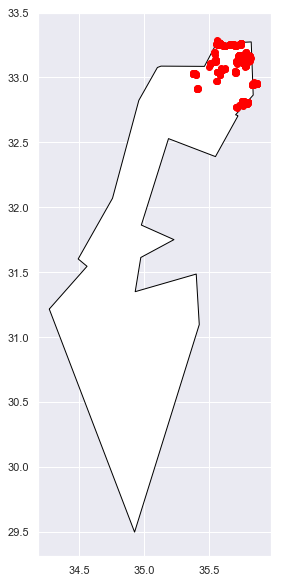

In [42]:
# We restrict to South America.
ax = israel.plot(
    color='white', edgecolor='black')

# We can now plot our GeoDataFrame.
data.plot(ax=ax, color='red')

plt.show()

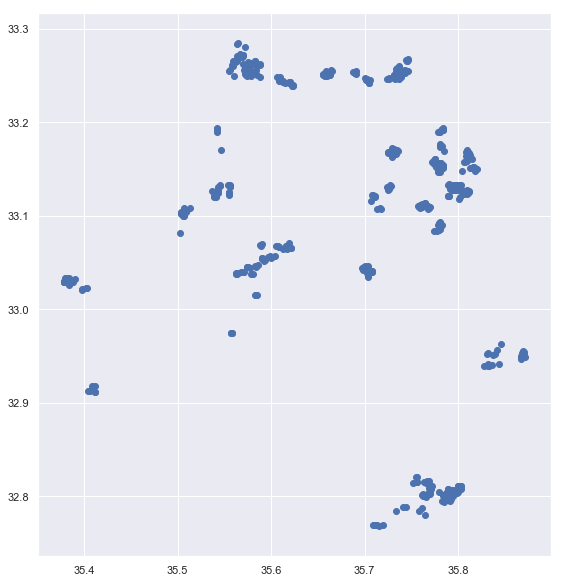

In [45]:
data.plot()

Show the distribution of crop types across the area.

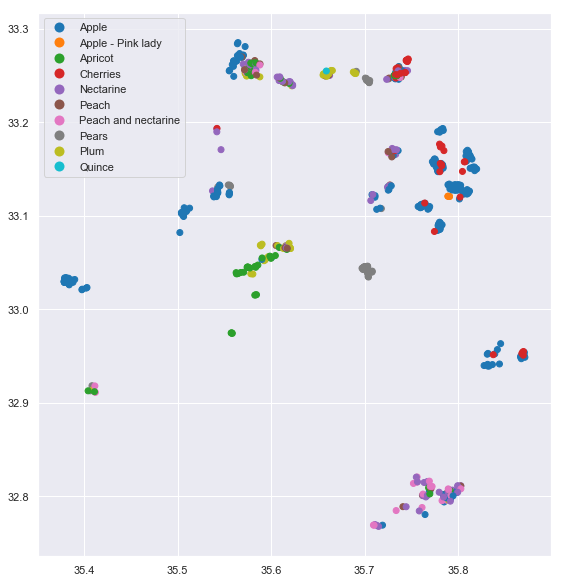

In [46]:
data.plot(column='Crop', legend=True)

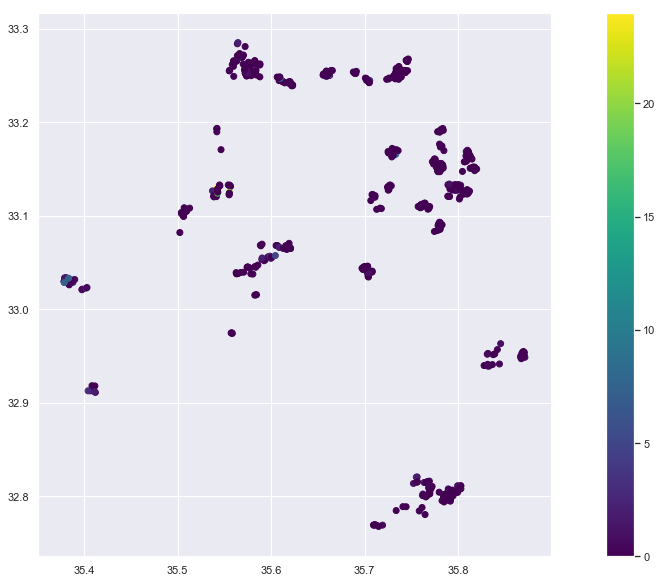

In [47]:
data.plot(column='Data', cmap='viridis', legend=True)

Creating a heatmap of overall pest infestation (all crops) using GMAPS.

In [61]:
df = data[['Data', 'Latitude', 'Longitude']]
df = df.dropna()

locations = df[['Latitude', 'Longitude']]
weights = df['Data']

fig = gmaps.figure() 
heatmap_layer = gmaps.heatmap_layer(locations, weights=weights) 
fig.add_layer(gmaps.heatmap_layer(locations, weights=weights)) 
fig

Figure(layout=FigureLayout(height=u'420px'))

Creating a HeatMap of Nectarine infestation using GMAPS.

In [49]:
df = data[data['Crop'] == 'Nectarine'][['Data', 'Latitude', 'Longitude']]
df = df.dropna()

locations = df[['Latitude', 'Longitude']]
weights = df['Data']

fig = gmaps.figure() 
heatmap_layer = gmaps.heatmap_layer(locations, weights=weights) 
fig.add_layer(gmaps.heatmap_layer(locations, weights=weights)) 
fig

Figure(layout=FigureLayout(height=u'420px'))

In [58]:
dates = data['Date/Time']

datetimes = dates.apply(lambda date: datetime.strptime(date, '%m/%d/%y %I:%M%p'))

AttributeError: 'module' object has no attribute 'strptime'

In [60]:
datetime.

<module 'datetime' from '/Users/rosskalter/anaconda2/lib/python2.7/lib-dynload/datetime.so'>

## HeatMap

/Users/rosskalter/anaconda2/lib/python2.7/site-packages/ipykernel_launcher.py:13: RuntimeWarning: divide by zero encountered in log
  del sys.path[0]


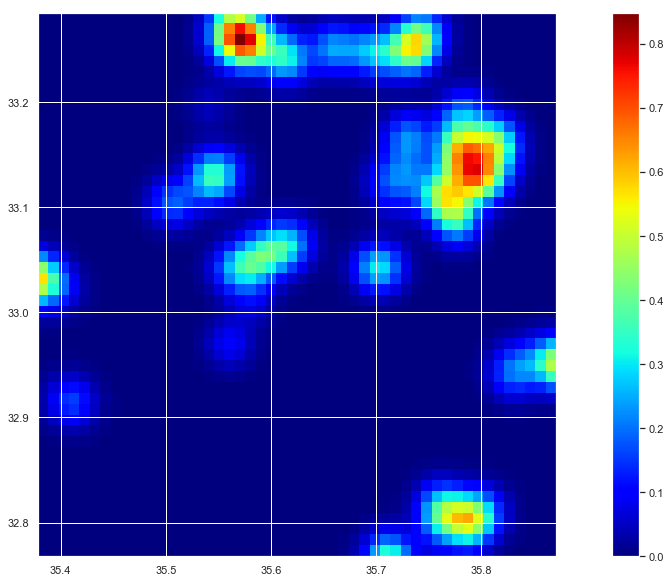

In [25]:
def heatmap(d, bins=(100,100), smoothing=1.3, cmap='jet'):
    def getx(pt):
        return pt.coords[0][0]

    def gety(pt):
        return pt.coords[0][1]

    x = list(d.geometry.apply(getx))
    y = list(d.geometry.apply(gety))
    heatmap, xedges, yedges = np.histogram2d(y, x, bins=bins)
    extent = [yedges[0], yedges[-1], xedges[-1], xedges[0]]

    logheatmap = np.log(heatmap)
    logheatmap[np.isneginf(logheatmap)] = 0
    logheatmap = ndimage.filters.gaussian_filter(logheatmap, smoothing, mode='nearest')
    
    plt.imshow(logheatmap, cmap=cmap, extent=extent)
    plt.colorbar()
    plt.gca().invert_yaxis()
    plt.show()

df = data.dropna()
heatmap(df, bins=50, smoothing=1.5)

## Kriging

Now_optimizing_for_q = 1 

Now_optimizing_for_q = 2 

Now_optimizing_for_q = 5 

Now_optimizing_for_q = 10 

Now_optimizing_for_q = 20 

Now_optimizing_for_q = 50 

Now_optimizing_for_q = 100 

Best_lh_found_using_q = 5 

Infill iteration 1 of 5....
Infill iteration 2 of 5....
Infill iteration 3 of 5....
Infill iteration 4 of 5....
Infill iteration 5 of 5....


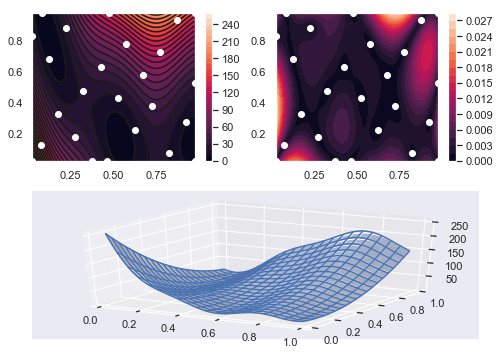

In [26]:
import pyKriging  
from pyKriging.krige import kriging  
from pyKriging.samplingplan import samplingplan

# The Kriging model starts by defining a sampling plan, we use an optimal Latin Hypercube here
sp = samplingplan(2)  
X = sp.optimallhc(20)

# Next, we define the problem we would like to solve
testfun = pyKriging.testfunctions().branin  
y = testfun(X)

# Now that we have our initial data, we can create an instance of a Kriging model
k = kriging(X, y, testfunction=testfun, name='simple')  
k.train()

# Now, five infill points are added. Note that the model is re-trained after each point is added
numiter = 5  
for i in range(numiter):  
    print 'Infill iteration {0} of {1}....'.format(i + 1, numiter)
    newpoints = k.infill(1)
    for point in newpoints:
        k.addPoint(point, testfun(point)[0])
    k.train()

# And plot the results
k.plot()  